# Random Forest - Sweeps

This notebook demonstrates how to use the Random Forest pipeline for predicting match outcomes between two teams, following the same structure as the XGBoost model.

## Setup and Imports

In [1]:
import sys

sys.path.append("..")

import dotenv
import pandas as pd

import wandb
from src.api.run import sweep_randomforest
from src.api.sweep import wandb_sweep

c:\Users\kybur\Repos\HSLU\aicomp\code\.venv\Lib\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
c:\Users\kybur\Repos\HSLU\aicomp\code\.venv\Lib\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because

In [2]:
dotenv.load_dotenv()
wandb.login()

wandb: Currently logged in as: v8-luky (aicomp-mmlm) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Experiments

In [3]:
max_runs = 100
sweep_config = {
    "name": "Random Forest",
    "method": "bayes",
    "metric": {"name": "valid_brier", "goal": "minimize"},
    "parameters": {
        "randomforest_config": {
            "parameters": {
                "n_estimators": {"distribution": "int_uniform", "min": 50, "max": 600},
                "max_depth": {"distribution": "int_uniform", "min": 5, "max": 50},
                "min_samples_split": {"distribution": "int_uniform", "min": 2, "max": 10},
                "min_samples_leaf": {"distribution": "int_uniform", "min": 1, "max": 5},
                "max_features": {"values": ["sqrt", "log2", None, 0.2, 0.5, 0.8]},
                "bootstrap": {"value": True},
                "max_samples": {"distribution": "uniform", "min": 0.2, "max": 0.8},
            },
        },
        "run_config": {
            "parameters": {
                "valid_season": {"value": 2024},
                "start_season": {"value": 2003},
                "num_features": {"distribution": "int_uniform", "min": 4, "max": 100},
            },
        },
    },
}

In [ ]:
wandb_sweep(sweep_config, sweep_randomforest, run_count=max_runs, project="random-forest")

## Submission from Best Model

In [3]:
from src.dataloaders.simple import SeasonAverageDataLoader
from src.experiments import DefaultTracker
from src.experiments.config import RunConfig
from src.models.randomforest import RandomForestHyperparamConfig, RandomForestRegressorModel
from src.submissions import create_submission

In [5]:
run = wandb.Api().run("random-forest/runs/bc45e7bx")
config = run.config
config

{'run_config': {'num_features': 4, 'start_season': 2003, 'valid_season': 2024},
 'randomforest_config': {'bootstrap': True,
  'max_depth': 6,
  'max_samples': 0.6904031179533447,
  'max_features': 'log2',
  'n_estimators': 261,
  'min_samples_leaf': 2,
  'min_samples_split': 6}}

In [6]:
run_config = RunConfig(**config.get("run_config", {}))
dataloader = SeasonAverageDataLoader(run_config.num_features)
run_config

RunConfig(num_features=4, valid_season=2024, start_season=2003, data_loader='season_average')

In [7]:
hyperparameters = RandomForestHyperparamConfig(**config.get("randomforest_config", {}))
hyperparameters

RandomForestHyperparamConfig(n_estimators=261, max_depth=6, min_samples_split=6, min_samples_leaf=2, max_features='log2', bootstrap=True, max_samples=0.6904031179533447, min_impurity_decrease=0.0, max_leaf_nodes=None, min_weight_fraction_leaf=0.0, random_state=42, n_jobs=-1, verbose=0, warm_start=False, ccp_alpha=0.0)

In [8]:
model = RandomForestRegressorModel(dataloader, hyperparameters, None, DefaultTracker({}))

In [20]:
season = 2025
create_submission(season=season, model=model, filename=f"random_forest_submission_{season}.csv", fit=True)

metrics: {'train_brier': np.float64(0.15205547796147378)}, step: None


WindowsPath('C:/Users/kybur/Repos/HSLU/aicomp/code/submissions/random_forest_submission_2025.csv')

## Feature Importance

In [ ]:
import matplotlib.pyplot as plt


def plot_feature_importances(
    model: RandomForestRegressorModel, dataloader: SeasonAverageDataLoader, run_config: RunConfig
):
    feature_names = dataloader.features[: run_config.num_features]
    importances = model.model.feature_importances_

    importance_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values(
        "importance", ascending=False
    )

    print("\nTop 10 Most Important Features:")
    print(importance_df.head(10))

    plt.figure(figsize=(10, 6))
    plt.barh(importance_df["feature"].head(25), importance_df["importance"].head(25))
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title("Top 15 Feature Importances - Random Forest Model")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

### Original Best Model

In [9]:
model.fit(season=2025, start_season=2003)

metrics: {'train_brier': np.float64(0.15205547796147378)}, step: None



Top 10 Most Important Features:
       feature  importance
0  QualityDiff    0.560991
1     SeedDiff    0.245008
2       T1_Elo    0.100652
3       T2_Elo    0.093349


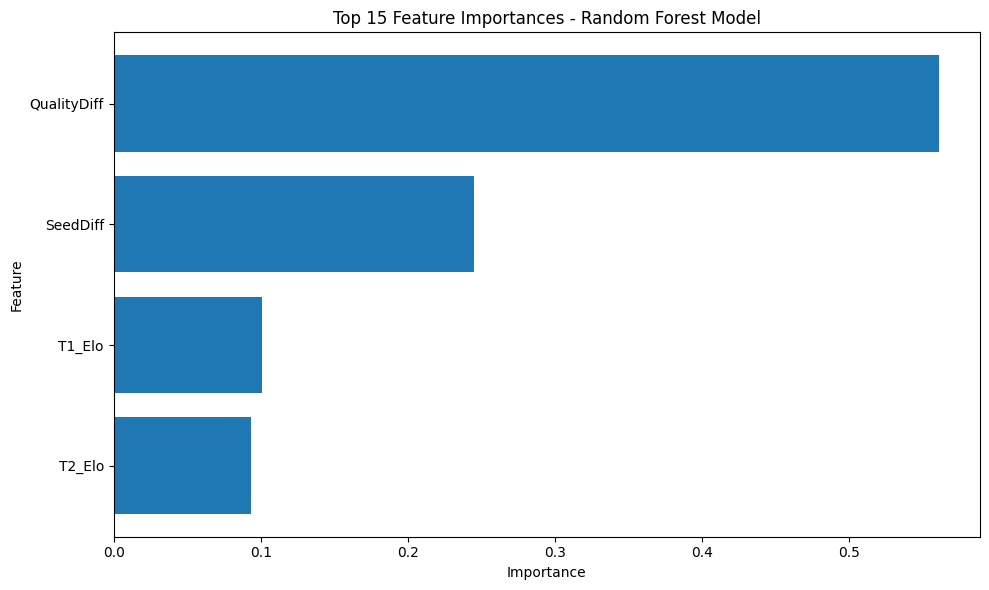

In [14]:
plot_feature_importances(model, dataloader, run_config)

### Best Model with all Features

In [16]:
run_config = RunConfig(valid_season=2025, start_season=2003, num_features=1000)
dataloader = SeasonAverageDataLoader(run_config.num_features)

In [18]:
model = RandomForestRegressorModel(dataloader, hyperparameters, None, DefaultTracker({}))

In [19]:
model.fit(season=run_config.valid_season, start_season=run_config.start_season)

metrics: {'train_brier': np.float64(0.14735074722386962)}, step: None



Top 10 Most Important Features:
                feature  importance
0           QualityDiff    0.144723
1              SeedDiff    0.104386
60              T2_seed    0.056422
63              T1_seed    0.051852
2                T1_Elo    0.050021
3                T2_Elo    0.049460
5            T2_avg_Elo    0.045502
4            T1_avg_Elo    0.039317
40  T1_avg_opponent_Elo    0.034463
21  T2_avg_opponent_Elo    0.030411


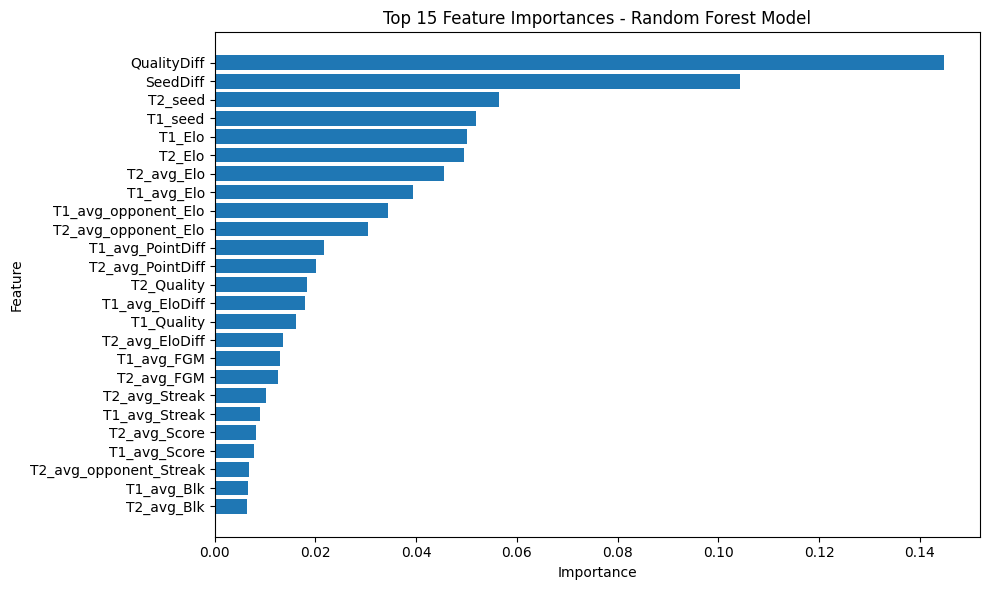

In [20]:
plot_feature_importances(model, dataloader, run_config)

## Sweep with Default Features

In [3]:
max_runs = 100
sweep_config = {
    "name": "Random Forest (Default Features)",
    "method": "bayes",
    "metric": {"name": "valid_brier", "goal": "minimize"},
    "parameters": {
        "randomforest_config": {
            "parameters": {
                "n_estimators": {"distribution": "int_uniform", "min": 50, "max": 600},
                "max_depth": {"distribution": "int_uniform", "min": 5, "max": 50},
                "min_samples_split": {"distribution": "int_uniform", "min": 2, "max": 10},
                "min_samples_leaf": {"distribution": "int_uniform", "min": 1, "max": 5},
                "max_features": {"values": ["sqrt", "log2", None, 0.2, 0.5, 0.8]},
                "bootstrap": {"value": True},
                "max_samples": {"distribution": "uniform", "min": 0.2, "max": 0.8},
            },
        },
        "run_config": {
            "parameters": {
                "valid_season": {"value": 2024},
                "start_season": {"value": 2003},
                "num_features": {"value": 0},
            },
        },
    },
}

In [ ]:
wandb_sweep(sweep_config, sweep_randomforest, run_count=max_runs, project="random-forest")

### Submission from Best Model

In [5]:
from src.dataloaders.simple import SeasonAverageDataLoader
from src.experiments import DefaultTracker
from src.experiments.config import RunConfig
from src.models.randomforest import RandomForestHyperparamConfig, RandomForestRegressorModel
from src.submissions import create_submission

In [6]:
run = wandb.Api().run("hkuxjnn5")
config = run.config
config

{'run_config': {'num_features': 0, 'start_season': 2003, 'valid_season': 2024},
 'randomforest_config': {'bootstrap': True,
  'max_depth': 5,
  'max_samples': 0.4129818724248994,
  'max_features': 0.5,
  'n_estimators': 360,
  'min_samples_leaf': 5,
  'min_samples_split': 6}}

In [7]:
run_config = RunConfig(**config.get("run_config", {}))
dataloader = SeasonAverageDataLoader(run_config.num_features)
run_config

RunConfig(num_features=0, valid_season=2024, start_season=2003, data_loader='season_average')

In [8]:
hyperparameters = RandomForestHyperparamConfig(**config.get("randomforest_config", {}))
hyperparameters

RandomForestHyperparamConfig(n_estimators=360, max_depth=5, min_samples_split=6, min_samples_leaf=5, max_features=0.5, bootstrap=True, max_samples=0.4129818724248994, min_impurity_decrease=0.0, max_leaf_nodes=None, min_weight_fraction_leaf=0.0, random_state=42, n_jobs=-1, verbose=0, warm_start=False, ccp_alpha=0.0)

In [9]:
model = RandomForestRegressorModel(dataloader, hyperparameters, None, DefaultTracker({}))

In [10]:
season = 2025
create_submission(
    season=season, model=model, filename=f"submission_random_forest_default_features_{season}.csv", fit=True
)

metrics: {'train_brier': np.float64(0.15336443956382304)}, step: None


WindowsPath('C:/Users/kybur/Repos/HSLU/aicomp/code/submissions/submission_random_forest_default_features_2025.csv')

## Sweep with Weighted Season Average DataLoader

In [3]:
max_runs = 100
sweep_config = {
    "name": "Random Forest (Weighted Season Average DataLoader)",
    "method": "bayes",
    "metric": {"name": "valid_brier", "goal": "minimize"},
    "parameters": {
        "randomforest_config": {
            "parameters": {
                "n_estimators": {"distribution": "int_uniform", "min": 50, "max": 600},
                "max_depth": {"distribution": "int_uniform", "min": 5, "max": 50},
                "min_samples_split": {"distribution": "int_uniform", "min": 2, "max": 10},
                "min_samples_leaf": {"distribution": "int_uniform", "min": 1, "max": 5},
                "max_features": {"values": ["sqrt", "log2", None, 0.2, 0.5, 0.8]},
                "bootstrap": {"value": True},
                "max_samples": {"distribution": "uniform", "min": 0.2, "max": 0.8},
            },
        },
        "run_config": {
            "parameters": {
                "valid_season": {"value": 2000},
                "start_season": {"value": 2000},
                "num_features": {"distribution": "int_uniform", "min": 4, "max": 100},
                "data_loader": {"value": "weighted_season_average"},
                "data_loader_config": {
                    "parameters": {
                        "regular_weight": {"distribution": "uniform", "min": 0.5, "max": 1.0},
                        "tourney_weight": {"distribution": "uniform", "min": 0.5, "max": 1.0},
                        "discount_factor": {"distribution": "uniform", "min": 0.9, "max": 1.0},
                    }
                },
            },
        },
    },
}

In [ ]:
wandb_sweep(sweep_config, sweep_randomforest, run_count=max_runs, project="random-forest")

### Submission from Best Model

In [3]:
from src.dataloaders.simple import SeasonAverageDataLoader
from src.experiments import DefaultTracker
from src.experiments.config import RunConfig
from src.models.randomforest import RandomForestHyperparamConfig, RandomForestRegressorModel
from src.submissions import create_submission

In [4]:
run = wandb.Api().run("random-forest/runs/5fowg053")
config = run.config
config

{'run_config': {'data_loader': 'weighted_season_average',
  'num_features': 5,
  'start_season': 2000,
  'valid_season': 2000,
  'data_loader_config': {'regular_weight': 0.6680395290169399,
   'tourney_weight': 0.7928965331824858,
   'discount_factor': 0.9968322286206586}},
 'randomforest_config': {'bootstrap': True,
  'max_depth': 10,
  'max_samples': 0.6566797964261799,
  'max_features': None,
  'n_estimators': 254,
  'min_samples_leaf': 2,
  'min_samples_split': 5}}

In [5]:
run_config = RunConfig(**config.get("run_config", {}))
dataloader = SeasonAverageDataLoader(run_config.num_features)
run_config

RunConfig(num_features=5, valid_season=2000, start_season=2000, data_loader='weighted_season_average', data_loader_config={'regular_weight': 0.6680395290169399, 'tourney_weight': 0.7928965331824858, 'discount_factor': 0.9968322286206586})

In [6]:
hyperparameters = RandomForestHyperparamConfig(**config.get("randomforest_config", {}))
hyperparameters

RandomForestHyperparamConfig(n_estimators=254, max_depth=10, min_samples_split=5, min_samples_leaf=2, max_features=None, bootstrap=True, max_samples=0.6566797964261799, min_impurity_decrease=0.0, max_leaf_nodes=None, min_weight_fraction_leaf=0.0, random_state=42, n_jobs=-1, verbose=0, warm_start=False, ccp_alpha=0.0)

In [7]:
model = RandomForestRegressorModel(dataloader, hyperparameters, None, DefaultTracker({}))

In [8]:
season = 2025
create_submission(season=season, model=model, filename=f"random_forest_submission_weighted_avg_{season}.csv", fit=True)

metrics: {'train_brier': np.float64(0.11137891226945393)}, step: None


WindowsPath('C:/Users/kybur/Repos/HSLU/aicomp/code/submissions/random_forest_submission_weighted_avg_2025.csv')